In [10]:
from typing import Annotated,TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END,add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from dotenv import load_dotenv
import os
load_dotenv()

True

In [13]:
os.environ['LANGSMITH_TRACING']='true'
os.environ['LANGSMITH_PROJECT']='Test'

In [4]:
model=ChatGroq(model='llama-3.3-70b-versatile')
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B51ED46FE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B51ED46EF0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [8]:
#  Graph with tool call
@tool
def add(a:float,b:float):
    """Add two numbers"""
    return a+b;

tool_node=ToolNode([add]) 

model_with_tools=model.bind_tools([add])

# node functionality
def tool_calling_llm(state:State):
    return{'messages':[model_with_tools.invoke(state['messages'])]}


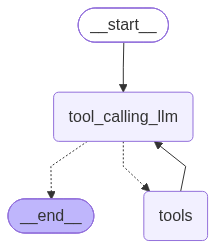

In [12]:
#Graph
builder=StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',tool_node)

#Add Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition)
builder.add_edge('tools','tool_calling_llm')

#compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
response=graph.invoke({'messages':'What is the latest news in India?'})
response

{'messages': [HumanMessage(content='What is the latest news in India?', additional_kwargs={}, response_metadata={}, id='c2d61198-358e-4080-b1b2-96b2941a45f4'),
  AIMessage(content="I'm not able to provide real-time news or updates. However, I can suggest some possible ways to find the latest news in India. \n\nYou can try searching online news websites such as The Times of India, The Hindu, or India Today for the latest news. Alternatively, you can also check social media platforms or news apps for updates. \n\nIf you're looking for a specific type of news, such as politics, sports, or entertainment, you can try searching for keywords related to that topic. \n\nPlease note that my knowledge cutoff is December 2023, so I may not have the most up-to-date information. For the latest news, it's always best to check reputable sources.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 220, 'total_tokens': 361, 'completion_time': 0.498003956

In [15]:
response=graph.invoke({'messages':'What is 2 plus 25?'})
response

{'messages': [HumanMessage(content='What is 2 plus 25?', additional_kwargs={}, response_metadata={}, id='3b0e0aab-15d6-4fac-8c55-9516f4be4dae'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6fsq9n9p4', 'function': {'arguments': '{"a":2,"b":25}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 220, 'total_tokens': 238, 'completion_time': 0.063000945, 'completion_tokens_details': None, 'prompt_time': 0.011958946, 'prompt_tokens_details': None, 'queue_time': 0.053599464, 'total_time': 0.074959891}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8ad4-407f-7820-a888-2caac091c9aa-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 25}, 'id': '6fsq9n9p4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens'